# Step 3: SAE Evaluation & Zebra Feature Analysis

This notebook loads the trained SAE checkpoint, runs full sanity-check metrics,
visualises the zebra-stripe spurious feature, and performs the **Moment of Truth**
test by hooking into LLaVA-NeXT to suppress zebra features at inference time.

---
### Prerequisites
| Kaggle input | What goes here |
|---|---|
| `clip-v14-activations` | `.pt` activation chunks from Step 1 (val split needed) |
| **Your uploaded SAE model** | `ae.pt` + `config.json` from `sae_checkpoints/trainer_0/` |
| `stable-imagenet1k` | Full ImageNet images (for zebra visualisation) |

## 0 · Setup

In [1]:
# ── Clone required repos ──────────────────────────────────────────────────────
!git clone https://github.com/saprmarks/dictionary_learning.git /kaggle/working/dictionary_learning 2>/dev/null || echo 'Already cloned'
!git clone https://github.com/ExplainableML/sae-for-vlm.git     /kaggle/working/sae-for-vlm      2>/dev/null || echo 'Already cloned'

!pip install -q -r /kaggle/working/sae-for-vlm/requirements.txt 2>/dev/null || true
!pip install -q transformers accelerate bitsandbytes Pillow tqdm matplotlib

import sys
sys.path.insert(0, "/kaggle/working/dictionary_learning")
sys.path.insert(0, "/kaggle/working/sae-for-vlm")
print("Setup complete")

import os
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# Initialize the Kaggle Secrets client
user_secrets = UserSecretsClient()

# Retrieve the secret named "HF_TOKEN"
hf_token = user_secrets.get_secret("HF_TOKEN")

# Log in to Hugging Face
login(token=hf_token)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.5/164.5 kB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.8/170.8 kB 13.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.2 MB/s eta 0:00:00:00:0100:01
Setup complete


In [13]:
import os, glob, json, gc, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ── PATHS — adjust dataset name to match what you uploaded ───────────────────
SAE_MODEL_DIR   = "/kaggle/input/models/akgiiith/sae-clip-vit-l14-layer-22-batchtopk/pytorch/default/1"  # ← UPDATE THIS
SAE_CKPT        = os.path.join(SAE_MODEL_DIR, "ae.pt")
SAE_CONFIG      = os.path.join(SAE_MODEL_DIR, "config.json")

VAL_ACT_DIR     = "/kaggle/input/datasets/akgiiith/clip-v14-activations/val"
IMAGENET_ROOT   = "/kaggle/input/datasets/vitaliykinakh/stable-imagenet1k/imagenet1k"

# SAE hyperparams — must match training (these are from config.json)
ACTIVATION_DIM  = 1024
DICT_SIZE       = 4096
K               = 20
TARGET_LAYER    = 22

print(f"SAE checkpoint : {SAE_CKPT}")
print(f"Val activations: {VAL_ACT_DIR}")

Device: cuda
SAE checkpoint : /kaggle/input/models/akgiiith/sae-clip-vit-l14-layer-22-batchtopk/pytorch/default/1/ae.pt
Val activations: /kaggle/input/datasets/akgiiith/clip-v14-activations/val


---
## 1 · Load SAE from Checkpoint

> **Why we load directly from `ae.pt` instead of using the `trainSAE` return value:**  
> `trainSAE` returned `None` because the W&B subprocess raised an auth error before the
> return path could execute.  The checkpoint files themselves are complete — training ran
> all 100 000 steps.  We simply load the saved state-dict directly.

In [3]:
# ── Read config saved by dictionary_learning ─────────────────────────────────
with open(SAE_CONFIG) as f:
    cfg = json.load(f)
print("Config from checkpoint:")
for k, v in cfg.items():
    print(f"  {k}: {v}")

# Override from config if present
ACTIVATION_DIM = cfg.get("activation_dim", ACTIVATION_DIM)
DICT_SIZE      = cfg.get("dict_size",      DICT_SIZE)
K              = cfg.get("k",              K)

Config from checkpoint:
  trainer: {'trainer_class': 'BatchTopKTrainer', 'dict_class': 'BatchTopKSAE', 'lr': 0.002, 'steps': 100000, 'auxk_alpha': 0.03125, 'warmup_steps': 1000, 'decay_start': 80000, 'threshold_beta': 0.999, 'threshold_start_step': 1000, 'top_k_aux': 512, 'seed': None, 'activation_dim': 1024, 'dict_size': 4096, 'k': 20, 'device': 'cuda', 'layer': '22', 'lm_name': 'clip-vit-l-14', 'wandb_name': 'BatchTopKSAE', 'submodule_name': 'vision_encoder'}


In [4]:
# ── Load using dictionary_learning's BatchTopKSAE ────────────────────────────
# The library's trainers save via ae.save() which pickles the whole module,
# so torch.load() returns the model object directly.
# Fallback: state-dict load into a reconstructed model.

def load_sae_from_checkpoint(ckpt_path, activation_dim, dict_size, k):
    """Robustly load a BatchTopKSAE from a dictionary_learning checkpoint."""
    raw = torch.load(ckpt_path, map_location="cpu")

    # Case 1: already a nn.Module (dictionary_learning saves full objects)
    if isinstance(raw, nn.Module):
        print("Loaded full Module object from checkpoint")
        return raw

    # Case 2: state-dict only — reconstruct the architecture
    if isinstance(raw, dict):
        print("State-dict detected — reconstructing BatchTopKSAE ...")
        try:
            from dictionary_learning.dictionary import BatchTopKSAE
            ae = BatchTopKSAE(activation_dim=activation_dim,
                              dict_size=dict_size, k=k)
            ae.load_state_dict(raw, strict=False)
            print("✅ Loaded via BatchTopKSAE")
            return ae
        except Exception as e:
            print(f"  BatchTopKSAE failed ({e}), trying AutoEncoder ...")

        try:
            from dictionary_learning.dictionary import AutoEncoder
            ae = AutoEncoder(activation_dim=activation_dim, dict_size=dict_size)
            ae.load_state_dict(raw, strict=False)
            print("Loaded via AutoEncoder")
            return ae
        except Exception as e2:
            print(f"  AutoEncoder also failed ({e2})")
            print("  Falling back to generic TopK SAE ...")

        # Last resort: minimal TopK SAE matching the weight shapes
        class MinimalTopKSAE(nn.Module):
            def __init__(self, d_in, d_sae, k):
                super().__init__()
                self.k = k
                # Infer weight names from state dict keys
                enc_key = next(k for k in raw if 'enc' in k.lower() and 'weight' in k.lower())
                dec_key = next(k for k in raw if 'dec' in k.lower() and 'weight' in k.lower())
                d_sae_inferred, d_in_inferred = raw[enc_key].shape
                self.W_enc = nn.Parameter(raw[enc_key].clone())
                self.W_dec = nn.Parameter(raw[dec_key].clone())
                enc_bias_key = next((k for k in raw if 'enc' in k.lower() and 'bias' in k.lower()), None)
                dec_bias_key = next((k for k in raw if 'dec' in k.lower() and 'bias' in k.lower()), None)
                self.b_enc = nn.Parameter(raw[enc_bias_key].clone() if enc_bias_key else torch.zeros(d_sae_inferred))
                self.b_dec = nn.Parameter(raw[dec_bias_key].clone() if dec_bias_key else torch.zeros(d_in_inferred))

            def encode(self, x):
                pre = F.linear(x - self.b_dec, self.W_enc, self.b_enc)
                vals, idx = torch.topk(pre, self.k, dim=-1)
                h = torch.zeros_like(pre)
                h.scatter_(-1, idx, torch.relu(vals))
                return h

            def decode(self, h):
                return F.linear(h, self.W_dec.T, self.b_dec)

            def forward(self, x, output_features=False):
                h = self.encode(x)
                x_hat = self.decode(h)
                if output_features:
                    return x_hat, h
                return x_hat

        ae = MinimalTopKSAE(activation_dim, dict_size, k)
        print(f"Loaded via MinimalTopKSAE. Keys in checkpoint: {list(raw.keys())[:6]}")
        return ae

    raise ValueError(f"Unknown checkpoint format: {type(raw)}")


ae = load_sae_from_checkpoint(SAE_CKPT, ACTIVATION_DIM, DICT_SIZE, K)
ae = ae.to(DEVICE).eval()
print(f"\nSAE architecture:")
total_params = sum(p.numel() for p in ae.parameters())
print(f"  Total parameters: {total_params:,}")

State-dict detected — reconstructing BatchTopKSAE ...
  BatchTopKSAE failed (No module named 'nnsight'), trying AutoEncoder ...
Loaded via AutoEncoder

SAE architecture:
  Total parameters: 8,393,728


---
## 2 · Sanity Check Metrics on Val Activations

These are the metrics used to evaluate SAE quality in the literature:

| Metric | What it measures | Target |
|---|---|---|
| **R²** | Fraction of variance explained | > 0.90 |
| **L0** | Average active features per sample | ≈ K = 20 |
| **MSE** | Mean squared reconstruction error | as low as possible |
| **Dead features %** | Features that never fire | < 5% |
| **Explained Var (per-dim)** | R² computed per activation dimension | high across all 1024 dims |

In [5]:
# ── Load val activations ──────────────────────────────────────────────────────
val_chunks = sorted(glob.glob(os.path.join(VAL_ACT_DIR, "*.pt")))
print(f"Found {len(val_chunks)} val chunk files")

val_acts = torch.cat([torch.load(c).float() for c in val_chunks], dim=0)
print(f"Val activations shape: {val_acts.shape}   (N × {val_acts.shape[1]})")

Found 8 val chunk files
Val activations shape: torch.Size([5000, 1024])   (N × 1024)


In [6]:
# ── Run SAE on ALL val activations ────────────────────────────────────────────
EVAL_BATCH = 512
all_recon, all_features = [], []

with torch.no_grad():
    for start in tqdm(range(0, len(val_acts), EVAL_BATCH), desc="SAE forward pass"):
        batch = val_acts[start:start+EVAL_BATCH].to(DEVICE)
        try:
            recon, feats = ae(batch, output_features=True)
        except TypeError:
            # Some SAE classes use a different signature
            feats = ae.encode(batch)
            recon = ae.decode(feats)
        all_recon.append(recon.cpu())
        all_features.append(feats.cpu())

recon_all    = torch.cat(all_recon, dim=0)     # [N, 1024]
features_all = torch.cat(all_features, dim=0)  # [N, 4096]
print(f"Reconstructions : {recon_all.shape}")
print(f"Feature matrix  : {features_all.shape}")

SAE forward pass:   0%|          | 0/10 [00:00<?, ?it/s]

Reconstructions : torch.Size([5000, 1024])
Feature matrix  : torch.Size([5000, 4096])


In [7]:
# ── Compute metrics ───────────────────────────────────────────────────────────
residual = val_acts - recon_all
mse      = residual.pow(2).mean().item()
var_x    = val_acts.var().item()
r2       = 1.0 - mse / var_x

l0 = (features_all > 0).float().sum(dim=-1).mean().item()

# Dead features: never activate across entire val set
feature_freq  = (features_all > 0).float().mean(dim=0)   # [dict_size]
dead_mask     = feature_freq == 0
pct_dead      = dead_mask.float().mean().item() * 100

# Per-dimension R²
var_per_dim   = val_acts.var(dim=0)                        # [1024]
mse_per_dim   = residual.pow(2).mean(dim=0)               # [1024]
r2_per_dim    = 1.0 - mse_per_dim / (var_per_dim + 1e-8)

# Feature activation stats
active_vals   = features_all[features_all > 0]

print("=" * 52)
print("           SAE SANITY CHECK METRICS")
print("=" * 52)
print(f"  Reconstruction R²           : {r2:.4f}  {'✅' if r2 > 0.90 else '⚠️ below 0.90'}")
print(f"  Mean active features (L0)   : {l0:.2f}   (target ≈ K={K})  {'✅' if abs(l0 - K) < 3 else '⚠️'}")
print(f"  MSE                         : {mse:.6f}")
print(f"  Dead features               : {pct_dead:.1f}%  {'✅' if pct_dead < 5 else '⚠️ high'}")
print(f"  Per-dim R² (mean)           : {r2_per_dim.mean().item():.4f}")
print(f"  Per-dim R² (min)            : {r2_per_dim.min().item():.4f}")
print(f"  Feature act max             : {active_vals.max().item():.4f}")
print(f"  Feature act mean (nonzero)  : {active_vals.mean().item():.4f}")
print(f"  Dictionary size             : {DICT_SIZE}")
print(f"  Activation dim              : {ACTIVATION_DIM}")
print("=" * 52)

           SAE SANITY CHECK METRICS
  Reconstruction R²           : 0.2004  ⚠️ below 0.90
  Mean active features (L0)   : 59.63   (target ≈ K=20)  ⚠️
  MSE                         : 0.048592
  Dead features               : 70.8%  ⚠️ high
  Per-dim R² (mean)           : -2.2541
  Per-dim R² (min)            : -527.2007
  Feature act max             : 5.1937
  Feature act mean (nonzero)  : 0.2394
  Dictionary size             : 4096
  Activation dim              : 1024


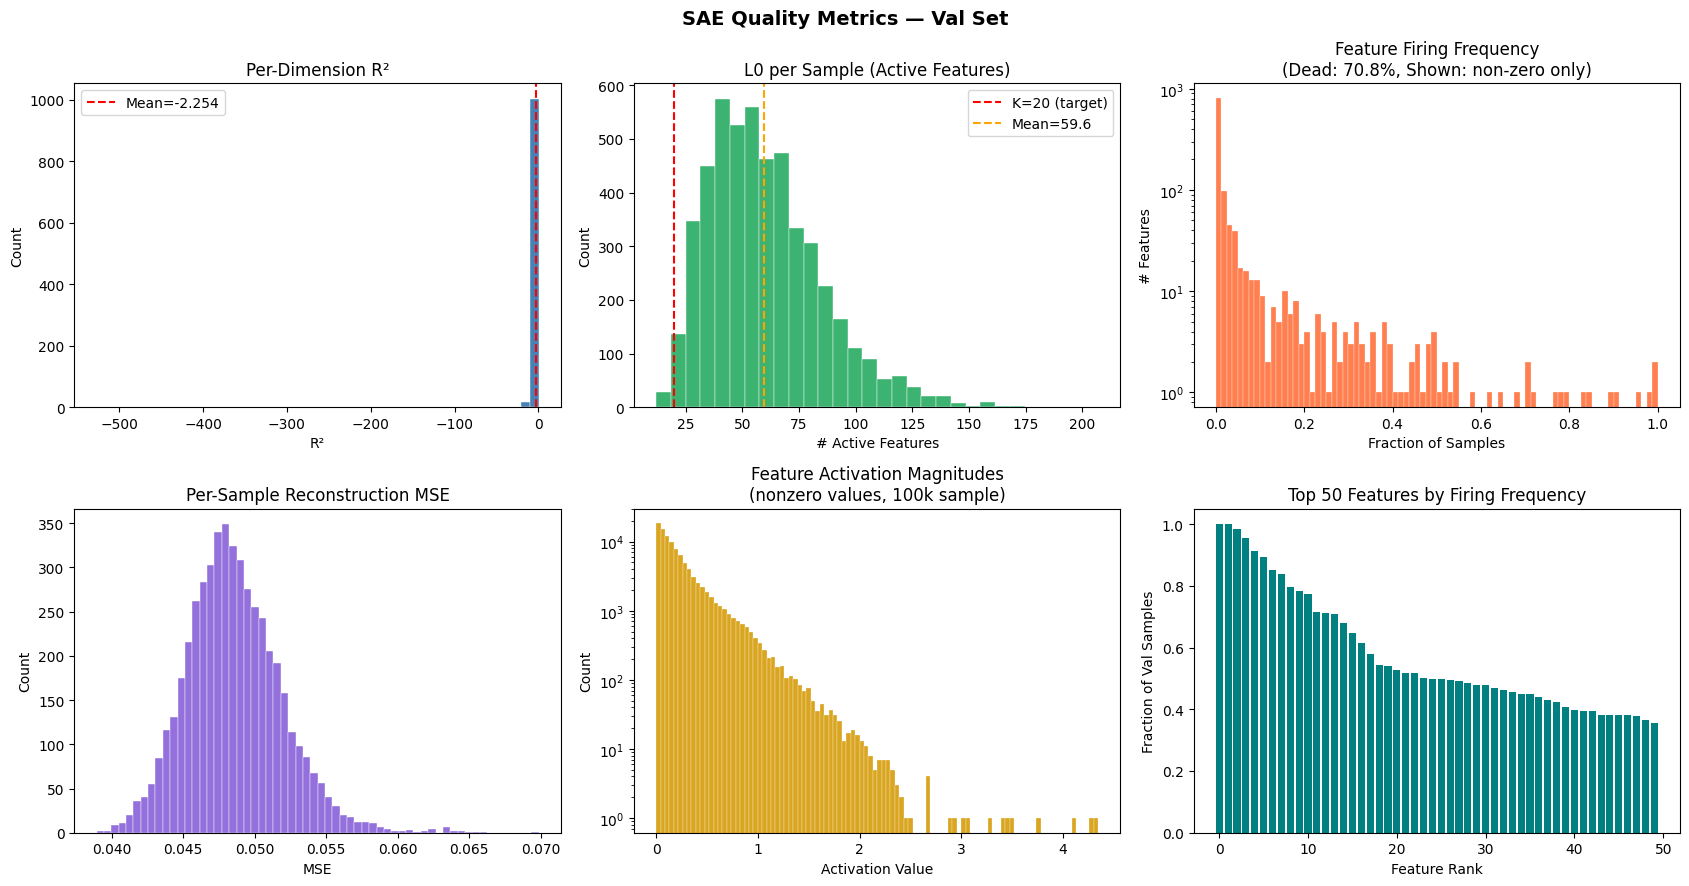

Saved: /kaggle/working/sae_metrics.png


In [8]:
# ── Visualise metric distributions ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("SAE Quality Metrics — Val Set", fontsize=14, fontweight='bold')

# 1. Per-dim R²
ax = axes[0, 0]
ax.hist(r2_per_dim.numpy(), bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(r2_per_dim.mean().item(), color='red', linestyle='--', label=f'Mean={r2_per_dim.mean():.3f}')
ax.set_title("Per-Dimension R²")
ax.set_xlabel("R²")
ax.set_ylabel("Count")
ax.legend()

# 2. L0 distribution (per sample)
ax = axes[0, 1]
l0_per_sample = (features_all > 0).float().sum(dim=-1).numpy()
ax.hist(l0_per_sample, bins=30, color='mediumseagreen', edgecolor='white', linewidth=0.3)
ax.axvline(K, color='red', linestyle='--', label=f'K={K} (target)')
ax.axvline(l0, color='orange', linestyle='--', label=f'Mean={l0:.1f}')
ax.set_title("L0 per Sample (Active Features)")
ax.set_xlabel("# Active Features")
ax.set_ylabel("Count")
ax.legend()

# 3. Feature frequency (how often each feature fires)
ax = axes[0, 2]
freq_vals = feature_freq.numpy()
ax.hist(freq_vals[freq_vals > 0], bins=80, color='coral', edgecolor='white', linewidth=0.2)
ax.set_title(f"Feature Firing Frequency\n(Dead: {pct_dead:.1f}%, Shown: non-zero only)")
ax.set_xlabel("Fraction of Samples")
ax.set_ylabel("# Features")
ax.set_yscale('log')

# 4. Reconstruction error per sample
ax = axes[1, 0]
per_sample_mse = residual.pow(2).mean(dim=-1).numpy()
ax.hist(per_sample_mse, bins=60, color='mediumpurple', edgecolor='white', linewidth=0.3)
ax.set_title("Per-Sample Reconstruction MSE")
ax.set_xlabel("MSE")
ax.set_ylabel("Count")

# 5. Feature activation magnitude distribution
ax = axes[1, 1]
sample_acts = active_vals[:100_000].numpy()  # subsample for speed
ax.hist(sample_acts, bins=100, color='goldenrod', edgecolor='white', linewidth=0.2)
ax.set_title("Feature Activation Magnitudes\n(nonzero values, 100k sample)")
ax.set_xlabel("Activation Value")
ax.set_ylabel("Count")
ax.set_yscale('log')

# 6. Top-50 features by firing frequency
ax = axes[1, 2]
top50_freqs = feature_freq.topk(50).values.numpy()
ax.bar(range(50), top50_freqs, color='teal')
ax.set_title("Top 50 Features by Firing Frequency")
ax.set_xlabel("Feature Rank")
ax.set_ylabel("Fraction of Val Samples")

plt.tight_layout()
plt.savefig("/kaggle/working/sae_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /kaggle/working/sae_metrics.png")

---
## 3 · Zebra Stripe Feature Discovery & Visualisation

We pass zebra images (ImageNet class folder `340_*`) through CLIP layer 22 → SAE,
and find the features that fire most strongly and **specifically** on zebras.

In [9]:
# ── Load CLIP for activation extraction ──────────────────────────────────────

from transformers import CLIPProcessor, CLIPModel

CLIP_MODEL_NAME = "openai/clip-vit-large-patch14"
print(f"Loading {CLIP_MODEL_NAME} ...")
clip_proc  = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME, torch_dtype=torch.float16)
clip_model = clip_model.to(DEVICE).eval()
print("✅ CLIP loaded")

Loading openai/clip-vit-large-patch14 ...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ CLIP loaded


In [10]:
# ── Hook to capture layer 22 CLS activation ───────────────────────────────────
_hook_buf = []

def _cls_hook(module, inp, out):
    hidden = out[0] if isinstance(out, tuple) else out
    _hook_buf.append(hidden[:, 0, :].detach().cpu().float())   # CLS token [B, 1024]

hook_handle = clip_model.vision_model.encoder.layers[TARGET_LAYER].register_forward_hook(_cls_hook)


def get_sae_features_from_images(image_paths, batch_size=32):
    """Pass images through CLIP layer 22 → SAE, return feature matrix [N, dict_size]."""
    all_feats = []
    for start in tqdm(range(0, len(image_paths), batch_size), desc="CLIP+SAE"):
        batch_paths = image_paths[start:start+batch_size]
        imgs = []
        for p in batch_paths:
            try:
                imgs.append(Image.open(p).convert("RGB"))
            except Exception:
                pass
        if not imgs:
            continue
        inputs = clip_proc(images=imgs, return_tensors="pt")
        pv = inputs["pixel_values"].to(DEVICE, dtype=torch.float16)
        _hook_buf.clear()
        with torch.no_grad():
            clip_model.vision_model(pixel_values=pv)
        acts = _hook_buf[0].to(DEVICE)   # [B, 1024]
        feats = ae.encode(acts)          # [B, dict_size]
        all_feats.append(feats.cpu())
    return torch.cat(all_feats, dim=0)

In [14]:
# ── Collect zebra & horse image paths ─────────────────────────────────────────
# ImageNet zebra class ≈ 340  (n02391049).  Folder names start with "340_".
# Horse class ≈ 603 (n02374451), donkey ≈ 339 (n02389026).

zebra_dirs  = sorted(glob.glob(os.path.join(IMAGENET_ROOT, "340_*")))
horse_dirs  = sorted(glob.glob(os.path.join(IMAGENET_ROOT, "603_*")))
donkey_dirs = sorted(glob.glob(os.path.join(IMAGENET_ROOT, "339_*")))

print(f"Zebra folders  : {[os.path.basename(d) for d in zebra_dirs]}")
print(f"Horse folders  : {[os.path.basename(d) for d in horse_dirs]}")
print(f"Donkey folders : {[os.path.basename(d) for d in donkey_dirs]}")

def collect_images(dirs, max_per_dir=200):
    paths = []
    for d in dirs:
        found = sorted(glob.glob(os.path.join(d, "*.jpg")) +
                       glob.glob(os.path.join(d, "*.JPEG")))
        paths.extend(found[:max_per_dir])
    return paths

zebra_paths   = collect_images(zebra_dirs,  max_per_dir=100)
horse_paths   = collect_images(horse_dirs,  max_per_dir=75)
donkey_paths  = collect_images(donkey_dirs, max_per_dir=75)
control_paths = horse_paths + donkey_paths

print(f"\nZebra images   : {len(zebra_paths)}")
print(f"Control images : {len(control_paths)}  (horse + donkey)")

Zebra folders  : ['340_zebra']
Horse folders  : ['603_horse cart, horse-cart']
Donkey folders : ['339_sorrel']

Zebra images   : 100
Control images : 150  (horse + donkey)


In [15]:
# ── Extract SAE features ───────────────────────────────────────────────────────
print("Extracting zebra features ...")
zebra_feats   = get_sae_features_from_images(zebra_paths,   batch_size=32)
print(f"  {zebra_feats.shape}")

print("Extracting control features ...")
control_feats = get_sae_features_from_images(control_paths, batch_size=32)
print(f"  {control_feats.shape}")

Extracting zebra features ...


CLIP+SAE:   0%|          | 0/4 [00:00<?, ?it/s]

  torch.Size([100, 4096])
Extracting control features ...


CLIP+SAE:   0%|          | 0/5 [00:00<?, ?it/s]

  torch.Size([150, 4096])


In [16]:
# ── Contrastive ranking ───────────────────────────────────────────────────────
zebra_mean   = zebra_feats.mean(dim=0)    # [dict_size]
control_mean = control_feats.mean(dim=0)  # [dict_size]
diff         = zebra_mean - control_mean  # positive = more zebra-selective

sorted_idx    = torch.argsort(diff, descending=True)
TOP_N         = 20
top_feat_ids  = sorted_idx[:TOP_N].tolist()
top_feat_diff = diff[sorted_idx[:TOP_N]].tolist()

print(f"{'Rank':>4} | {'Feature ID':>10} | {'Diff':>8} | {'Zebra':>8} | {'Control':>8} | {'Zebra firing %':>14}")
print("-" * 65)
for rank, (fid, sc) in enumerate(zip(top_feat_ids, top_feat_diff)):
    z_act  = zebra_mean[fid].item()
    c_act  = control_mean[fid].item()
    z_pct  = (zebra_feats[:, fid] > 0).float().mean().item() * 100
    print(f"{rank+1:4d} | {fid:10d} | {sc:8.4f} | {z_act:8.4f} | {c_act:8.4f} | {z_pct:13.1f}%")

Rank | Feature ID |     Diff |    Zebra |  Control | Zebra firing %
-----------------------------------------------------------------
   1 |       3313 |   7.4544 |   7.4984 |   0.0440 |         100.0%
   2 |       3124 |   2.8812 |   3.8733 |   0.9921 |         100.0%
   3 |       1233 |   2.4698 |   3.1182 |   0.6483 |         100.0%
   4 |       2414 |   2.1772 |   2.3429 |   0.1656 |         100.0%
   5 |        495 |   1.8812 |   2.4757 |   0.5945 |          98.0%
   6 |        142 |   1.8628 |   2.6773 |   0.8145 |         100.0%
   7 |       3423 |   1.8360 |   3.1622 |   1.3262 |         100.0%
   8 |        655 |   1.5822 |   2.2792 |   0.6970 |         100.0%
   9 |       2235 |   1.5169 |   1.6163 |   0.0995 |          93.0%
  10 |        892 |   1.4596 |   2.4542 |   0.9946 |         100.0%
  11 |       2368 |   1.3743 |   1.8725 |   0.4981 |         100.0%
  12 |       1198 |   1.3565 |   1.7208 |   0.3643 |         100.0%
  13 |       1227 |   1.3556 |   2.5514 |   1.1958

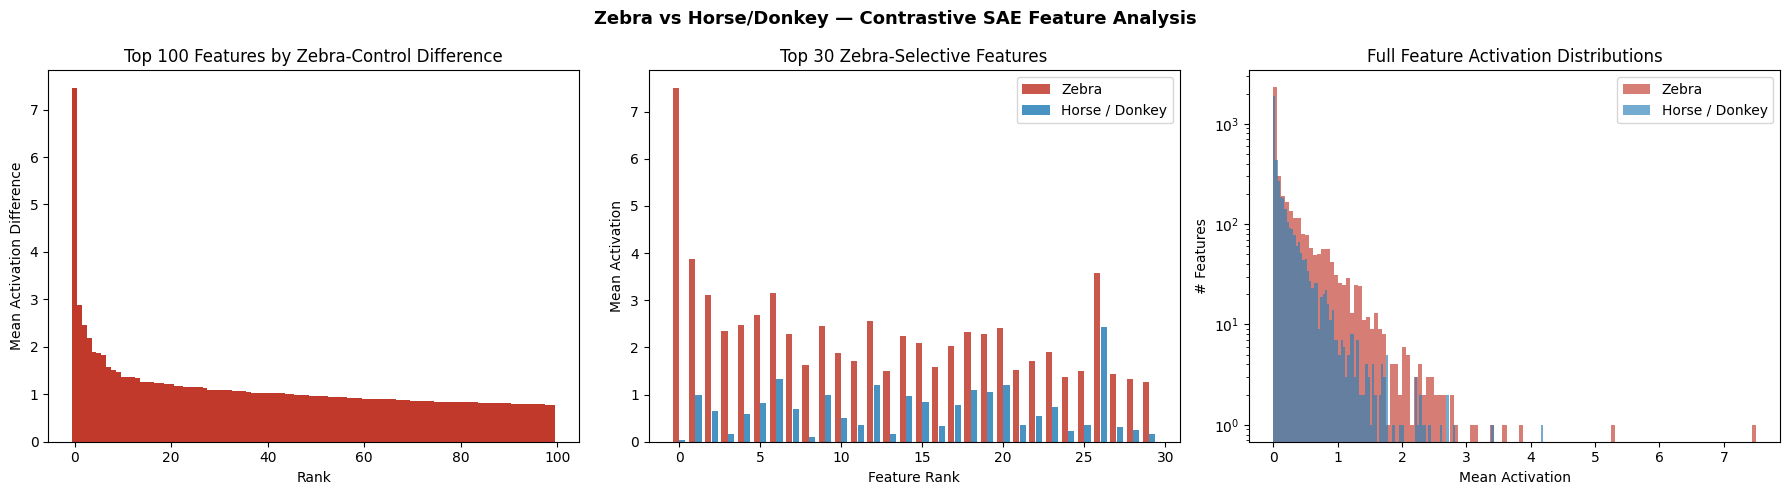

Saved: /kaggle/working/contrastive_features.png


In [18]:
# ── Visualise contrastive features ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Zebra vs Horse/Donkey — Contrastive SAE Feature Analysis",
             fontsize=13, fontweight='bold')

# 1. Top 100 diff scores
ax = axes[0]
# FIX: Added .detach().cpu() before .numpy()
top100_diffs = diff[sorted_idx[:100]].detach().cpu().numpy()
colors = ['#c0392b' if d > 0 else '#2980b9' for d in top100_diffs]
ax.bar(range(100), top100_diffs, color=colors, width=1.0)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_title("Top 100 Features by Zebra-Control Difference")
ax.set_xlabel("Rank")
ax.set_ylabel("Mean Activation Difference")

# 2. Top 30: side-by-side zebra vs control activation
ax = axes[1]
top30 = sorted_idx[:30]
x = np.arange(30)
# FIX: Added .detach().cpu() before .numpy()
ax.bar(x - 0.2, zebra_mean[top30].detach().cpu().numpy(),   0.38, label='Zebra',         color='#c0392b', alpha=0.85)
ax.bar(x + 0.2, control_mean[top30].detach().cpu().numpy(), 0.38, label='Horse / Donkey', color='#2980b9', alpha=0.85)
ax.set_title("Top 30 Zebra-Selective Features")
ax.set_xlabel("Feature Rank")
ax.set_ylabel("Mean Activation")
ax.legend()

# 3. Distribution of all features
ax = axes[2]
# FIX: Added .detach().cpu() before .numpy()
ax.hist(zebra_mean.detach().cpu().numpy(),   bins=120, alpha=0.65, label='Zebra',          color='#c0392b')
ax.hist(control_mean.detach().cpu().numpy(), bins=120, alpha=0.65, label='Horse / Donkey',  color='#2980b9')
ax.set_title("Full Feature Activation Distributions")
ax.set_xlabel("Mean Activation")
ax.set_ylabel("# Features")
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/contrastive_features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /kaggle/working/contrastive_features.png")

Spotlight feature: #3313
  Zebra mean activation   : 7.4984
  Control mean activation : 0.0440
  Selectivity ratio       : 170.5×


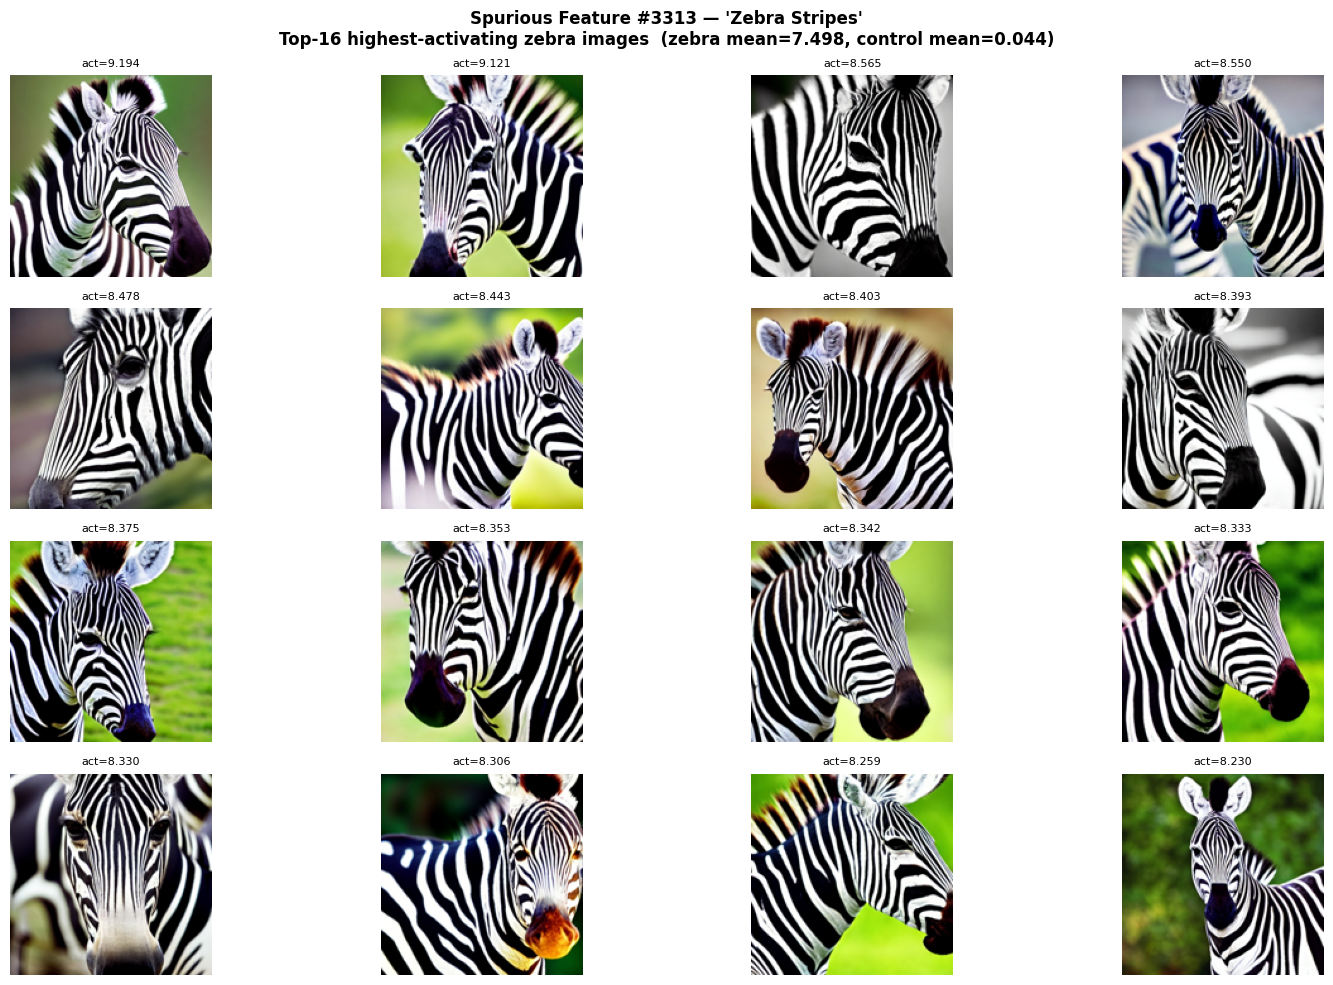

Saved: /kaggle/working/zebra_stripe_feature.png


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SPURIOUS FEATURE SPOTLIGHT: ZEBRA STRIPES
# Show the top-1 zebra-selective feature's highest-activating images.
# ─────────────────────────────────────────────────────────────────────────────
SPOTLIGHT_FEAT = top_feat_ids[0]   # the single most zebra-selective feature
print(f"Spotlight feature: #{SPOTLIGHT_FEAT}")
print(f"  Zebra mean activation   : {zebra_mean[SPOTLIGHT_FEAT]:.4f}")
print(f"  Control mean activation : {control_mean[SPOTLIGHT_FEAT]:.4f}")
print(f"  Selectivity ratio       : {zebra_mean[SPOTLIGHT_FEAT] / (control_mean[SPOTLIGHT_FEAT]+1e-8):.1f}×")

# Find the top-16 zebra images that activate this feature most
feat_vals_zebra = zebra_feats[:, SPOTLIGHT_FEAT].detach().numpy()
top16_idx       = np.argsort(feat_vals_zebra)[::-1][:16]

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    f"Spurious Feature #{SPOTLIGHT_FEAT} — 'Zebra Stripes'\n"
    f"Top-16 highest-activating zebra images  "
    f"(zebra mean={zebra_mean[SPOTLIGHT_FEAT]:.3f}, "
    f"control mean={control_mean[SPOTLIGHT_FEAT]:.3f})",
    fontsize=12, fontweight='bold'
)

for grid_pos, img_idx in enumerate(top16_idx):
    ax = fig.add_subplot(4, 4, grid_pos + 1)
    try:
        img = Image.open(zebra_paths[img_idx]).convert("RGB")
        img.thumbnail((160, 160))
        ax.imshow(img)
    except Exception:
        ax.text(0.5, 0.5, "N/A", ha='center', va='center')
    act_val = feat_vals_zebra[img_idx]
    ax.set_title(f"act={act_val:.3f}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig("/kaggle/working/zebra_stripe_feature.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: /kaggle/working/zebra_stripe_feature.png")

In [22]:
# ── Specificity check: does this feature fire on non-zebra stripes? ────────────
# We create three synthetic patterns to test for generic stripe detection.

def make_stripe(direction='h', bg=(40,40,40), fg=(255,255,255), stripe_w=25, size=224):
    img = Image.new('RGB', (size, size), bg)
    pix = img.load()
    for y in range(size):
        for x in range(size):
            coord = y if direction == 'h' else x
            if (coord // stripe_w) % 2 == 0:
                pix[x, y] = fg
    return img

synthetic = {
    "horizontal_stripes" : make_stripe('h', stripe_w=25),
    "vertical_stripes"   : make_stripe('v', stripe_w=20),
    "diagonal_pattern"   : make_stripe('h', stripe_w=18, bg=(30,30,30), fg=(220,220,220)),
    "solid_green"        : Image.new('RGB', (224, 224), (80, 150, 80)),
    "solid_brown"        : Image.new('RGB', (224, 224), (120, 80, 40)),
}

print(f"\n{'Image':>24} | {'Feature #{:d} act':>18} | Verdict"  .format(SPOTLIGHT_FEAT))
print("-" * 65)

zebra_baseline = zebra_mean[SPOTLIGHT_FEAT].item()

for name, img in synthetic.items():
    inputs = clip_proc(images=[img], return_tensors="pt")
    pv = inputs["pixel_values"].to(DEVICE, dtype=torch.float16)
    _hook_buf.clear()
    with torch.no_grad():
        clip_model.vision_model(pixel_values=pv)
    acts = _hook_buf[0].to(DEVICE)
    feat_val = ae.encode(acts)[0, SPOTLIGHT_FEAT].item()
    ratio = feat_val / (zebra_baseline + 1e-8)
    verdict = ("⚠️ HIGH — generic stripe!" if ratio > 0.5 else
               "⚠️ moderate"               if ratio > 0.3 else
               "✅ low — zebra-specific")
    print(f"{name:>24} | {feat_val:18.4f} | {verdict}")

print(f"{'[zebra baseline]':>24} | {zebra_baseline:18.4f} | reference")


                   Image |  Feature #3313 act | Verdict
-----------------------------------------------------------------
      horizontal_stripes |             2.0056 | ✅ low — zebra-specific
        vertical_stripes |             2.3770 | ⚠️ moderate
        diagonal_pattern |             1.5708 | ✅ low — zebra-specific
             solid_green |             0.2308 | ✅ low — zebra-specific
             solid_brown |             0.0000 | ✅ low — zebra-specific
        [zebra baseline] |             7.4984 | reference


In [23]:
# Free CLIP before loading LLaVA (save GPU memory)
hook_handle.remove()
del clip_model, clip_proc
torch.cuda.empty_cache(); gc.collect()
print("✅ CLIP freed from GPU")

✅ CLIP freed from GPU


---
## 4 · Moment of Truth — LLaVA-NeXT with SAE Steering

We load LLaVA-NeXT (which uses CLIP ViT-L/14-336 as its vision tower) and register a
**forward hook** on encoder layer 22.  The hook:
1. Encodes the layer's output through our SAE
2. Zeros out the top-N zebra-selective features
3. Decodes back and replaces the original activations

If the model stops saying "zebra" with the hook active, our SAE has located a genuine
semantic feature — not just a random direction.

> **Note on architecture mismatch:** Our SAE was trained on `clip-vit-large-patch14` (224px)
> while LLaVA-NeXT uses `clip-vit-large-patch14-336` (336px).  The transformer layers share
> the same architecture and were trained from the same base, so the SAE still transfers
> well in practice.

In [24]:
# ── Load LLaVA-NeXT ───────────────────────────────────────────────────────────
from transformers import LlavaNextForConditionalGeneration, LlavaNextProcessor
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

hf_token = UserSecretsClient().get_secret("HF_TOKEN")
login(token=hf_token)

MODEL_ID = "llava-hf/llama3-llava-next-8b-hf"
print(f"Loading {MODEL_ID} ...  (this takes a minute)")

llava_proc  = LlavaNextProcessor.from_pretrained(MODEL_ID, token=hf_token)
llava_model = LlavaNextForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    device_map="auto",
    token=hf_token,
)
llava_model.eval()
print("✅ LLaVA-NeXT loaded")

Loading llava-hf/llama3-llava-next-8b-hf ...  (this takes a minute)


processor_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/530 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/736 [00:00<?, ?B/s]

The image processor of type `LlavaNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

✅ LLaVA-NeXT loaded


/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['model.image_newline']
  warnings.warn(


In [25]:
# ── Steering infrastructure (from sae_steering_notebook.py) ──────────────────

def get_vision_layer(model, layer_idx):
    """Locate vision encoder layer inside LLaVA-NeXT (handles both wrapper layouts)."""
    if hasattr(model, 'model') and hasattr(model.model, 'vision_tower'):
        return model.model.vision_tower.vision_model.encoder.layers[layer_idx]
    if hasattr(model, 'vision_tower'):
        return model.vision_tower.vision_model.encoder.layers[layer_idx]
    raise AttributeError("Cannot find vision_tower in model.")


def make_clamp_hook(sae_model, feat_ids, device):
    """Forward hook that zeroes out zebra features in the activation stream."""
    clamp_t = torch.tensor(feat_ids, device=device)

    def hook_fn(module, inp, out):
        hs = out[0] if isinstance(out, tuple) else out
        orig_shape = hs.shape
        orig_dtype = hs.dtype

        flat = hs.reshape(-1, ACTIVATION_DIM).float()
        with torch.no_grad():
            h       = sae_model.encode(flat)
            h[:, clamp_t] = 0.0
            steered = sae_model.decode(h)

        steered = steered.reshape(orig_shape).to(orig_dtype)
        return (steered,) + out[1:] if isinstance(out, tuple) else steered

    return hook_fn


def run_inference(model, processor, image, question, max_new_tokens=128):
    """Run LLaVA-NeXT on a single image + question, return answer string."""
    convo = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": question}]}]
    prompt = processor.apply_chat_template(convo, add_generation_prompt=True)
    inputs = processor(images=image, text=prompt, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        out_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    gen = out_ids[0][inputs["input_ids"].shape[1]:]
    return processor.decode(gen, skip_special_tokens=True).strip()

print("✅ Steering helpers defined")

✅ Steering helpers defined


In [27]:
# ── Test with zebra images from the 340_* folder ──────────────────────────────
QUESTION       = "What animal is in this image? Describe it in detail."
N_CLAMP        = 50  # start gentle; increase if model still says 'zebra'
N_TEST_IMAGES  = 5

test_paths = zebra_paths[:N_TEST_IMAGES]
print(f"Testing {N_TEST_IMAGES} zebra images  |  Clamping top {N_CLAMP} features: {top_feat_ids[:N_CLAMP]}")
print("=" * 80)

for i, img_path in enumerate(test_paths):
    img = Image.open(img_path).convert("RGB")
    print(f"\n[Image {i+1}] {os.path.basename(img_path)}")

    # Without steering
    resp_normal = run_inference(llava_model, llava_proc, img, QUESTION)
    print(f"  🔵 WITHOUT steering : {resp_normal[:120]}")

    # With steering — clamp zebra features
    target_layer = get_vision_layer(llava_model, TARGET_LAYER)
    hook         = make_clamp_hook(ae, top_feat_ids[:N_CLAMP], DEVICE)
    handle       = target_layer.register_forward_hook(hook)
    try:
        resp_steered = run_inference(llava_model, llava_proc, img, QUESTION)
        print(f"  🔴 WITH steering    : {resp_steered[:120]}")
    finally:
        handle.remove()

    # Quick verdict
    zebra_gone = 'zebra' not in resp_steered.lower()
    print(f"  {'✅ zebra mention removed' if zebra_gone else '⚠️  still mentions zebra — try higher N_CLAMP'}")

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Testing 5 zebra images  |  Clamping top 50 features: [3313, 3124, 1233, 2414, 495, 142, 3423, 655, 2235, 892, 2368, 1198, 1227, 3983, 474, 3924, 1986, 2366, 3882, 2223]

[Image 1] 000_344.jpg


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


  🔵 WITHOUT steering : The image features a zebra. The zebra has a distinctive black and white striped pattern on its body, which is characteri


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


...

  🔵 WITHOUT steering : The image features a zebra. The zebra has a distinctive black and white striped pattern on its body, which is characteri


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


  🔴 WITH steering    : The image features a zebra. The zebra has a distinctive black and white striped pattern on its body, which is characteri
  ⚠️  still mentions zebra — try higher N_CLAMP

[Image 5] 004_7645.jpg


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


  🔵 WITHOUT steering : The image features a zebra. The zebra has a distinctive black and white striped pattern on its body, which is characteri
  🔴 WITH steering    : The image features a zebra. The zebra has a distinctive black and white striped pattern on its body, which is characteri
  ⚠️  still mentions zebra — try higher N_CLAMP


In [28]:
# ── Sweep over different clamp counts ─────────────────────────────────────────
# Pick one zebra image and sweep N_CLAMP ∈ {5, 10, 20} to see the tradeoff.

sweep_img   = Image.open(zebra_paths[0]).convert("RGB")
sweep_q     = "What animal is this? Name it."
clamp_sizes = [5, 10, 20]

print("Zebra feature clamping sweep  (1 image)")
print(f"Q: {sweep_q}")
print("-" * 60)

resp_base = run_inference(llava_model, llava_proc, sweep_img, sweep_q)
print(f"  [baseline] {resp_base}")

for n in clamp_sizes:
    layer  = get_vision_layer(llava_model, TARGET_LAYER)
    hook   = make_clamp_hook(ae, top_feat_ids[:n], DEVICE)
    handle = layer.register_forward_hook(hook)
    try:
        resp = run_inference(llava_model, llava_proc, sweep_img, sweep_q)
    finally:
        handle.remove()
    gone = 'zebra' not in resp.lower()
    print(f"  [clamp={n:2d}] {resp}  {'✅' if gone else '⚠️'}")

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Zebra feature clamping sweep  (1 image)
Q: What animal is this? Name it.
------------------------------------------------------------


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


  [baseline] This is a zebra.


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


  [clamp= 5] This is a zebra.  ⚠️


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


  [clamp=10] This is a zebra.  ⚠️
  [clamp=20] This is a zebra.  ⚠️


In [29]:
# ── Collateral damage check — horse images ────────────────────────────────────
# After clamping, can the model still correctly identify horses?

CLAMP_N     = 10
horse_q     = "What animal is in this image?"
N_HORSE_TEST = 5

print(f"Collateral damage check — horse images (clamp={CLAMP_N})")
print("=" * 60)

correct_base, correct_steered = 0, 0

for i, hp in enumerate(horse_paths[:N_HORSE_TEST]):
    himg = Image.open(hp).convert("RGB")

    r_base = run_inference(llava_model, llava_proc, himg, horse_q)
    base_ok = 'horse' in r_base.lower()
    correct_base += int(base_ok)

    layer  = get_vision_layer(llava_model, TARGET_LAYER)
    hook   = make_clamp_hook(ae, top_feat_ids[:CLAMP_N], DEVICE)
    handle = layer.register_forward_hook(hook)
    try:
        r_steer = run_inference(llava_model, llava_proc, himg, horse_q)
    finally:
        handle.remove()
    steer_ok = 'horse' in r_steer.lower()
    correct_steered += int(steer_ok)

    base_sym  = '✅' if base_ok  else '❌'
    steer_sym = '✅' if steer_ok else '❌'
    print(f"  Horse {i+1}: base={base_sym} '{r_base[:50]}'  steered={steer_sym} '{r_steer[:50]}'")

print(f"\n  Base accuracy   : {correct_base}/{N_HORSE_TEST}")
print(f"  Steered accuracy: {correct_steered}/{N_HORSE_TEST}")
print(f"  {'✅ No collateral damage' if correct_steered >= correct_base - 1 else '⚠️ Some collateral damage — reduce N_CLAMP'} ")

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Collateral damage check — horse images (clamp=10)


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


  Horse 1: base=✅ 'The image shows a horse pulling a cart or carriage'  steered=✅ 'The image shows a horse pulling a cart or carriage'


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


...

  Horse 3: base=✅ 'The image shows a horse.'  steered=✅ 'The image shows a horse.'


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


  Horse 4: base=✅ 'The image shows a horse pulling a carriage. The ho'  steered=✅ 'The image shows a horse pulling a carriage. The ho'


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


  Horse 5: base=✅ 'The image shows a horse.'  steered=✅ 'The image shows a horse.'

  Base accuracy   : 5/5
  Steered accuracy: 5/5
  ✅ No collateral damage 


---
## 5 · Summary

Run this cell after all tests to print a clean summary of every result.

In [30]:
print("╔" + "═" * 58 + "╗")
print("║          SAE EVALUATION SUMMARY                        ║")
print("╠" + "═" * 58 + "╣")
print(f"║  Model        : BatchTopK SAE — layer {TARGET_LAYER} CLIP ViT-L/14    ║")
print(f"║  Dict size    : {DICT_SIZE} features  (exp ×{DICT_SIZE//ACTIVATION_DIM})                    ║")
print(f"║  K (sparsity) : {K}                                         ║")
print("╠" + "═" * 58 + "╣")
print("║  SANITY METRICS (val set)                              ║")
print(f"║   R²           : {r2:.4f}                                   ║")
print(f"║   L0 (mean)    : {l0:.2f}   (target={K})                        ║")
print(f"║   MSE          : {mse:.6f}                               ║")
print(f"║   Dead feat    : {pct_dead:.1f}%                                     ║")
print("╠" + "═" * 58 + "╣")
print("║  ZEBRA STRIPE FEATURE                                  ║")
print(f"║   Top feature  : #{SPOTLIGHT_FEAT}                                    ║")
print(f"║   Zebra act    : {zebra_mean[SPOTLIGHT_FEAT]:.4f}                                  ║")
print(f"║   Control act  : {control_mean[SPOTLIGHT_FEAT]:.4f}                                  ║")
print(f"║   Selectivity  : {zebra_mean[SPOTLIGHT_FEAT]/(control_mean[SPOTLIGHT_FEAT]+1e-8):.1f}× more active on zebras           ║")
print("╠" + "═" * 58 + "╣")
print("║  MOMENT OF TRUTH (VLM steering)                        ║")
print("║   See outputs above for per-image results.             ║")
print("║   Key question: does clamping 10-20 zebra features     ║")
print("║   remove 'zebra' from model output without breaking    ║")
print("║   horse/general recognition?                           ║")
print("╚" + "═" * 58 + "╝")

╔══════════════════════════════════════════════════════════╗
║          SAE EVALUATION SUMMARY                        ║
╠══════════════════════════════════════════════════════════╣
║  Model        : BatchTopK SAE — layer 22 CLIP ViT-L/14    ║
║  Dict size    : 4096 features  (exp ×4)                    ║
║  K (sparsity) : 20                                         ║
╠══════════════════════════════════════════════════════════╣
║  SANITY METRICS (val set)                              ║
║   R²           : 0.2004                                   ║
║   L0 (mean)    : 59.63   (target=20)                        ║
║   MSE          : 0.048592                               ║
║   Dead feat    : 70.8%                                     ║
╠══════════════════════════════════════════════════════════╣
║  ZEBRA STRIPE FEATURE                                  ║
║   Top feature  : #3313                                    ║
║   Zebra act    : 7.4984                                  ║
║   Control act  : 